In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.colors as mcolors


In [ ]:
pcr_sero = pd.read_excel("PA Y1 and Y2 Metadata with PCR and Serology.xlsx", sheet_name="Sheet1")
#pcr_sero['Collection Date'] = pd.to_datetime(pcr_sero['Harvest Date'], errors='coerce')
pcr_sero["MonthYear"] = pcr_sero["Collection Date"].dt.to_period("M").dt.to_timestamp()

pcr_sero["Semester"] = np.where(
    pcr_sero["MonthYear"].dt.month.isin([9, 10, 11, 12]),       
    "Fall "   + pcr_sero["MonthYear"].dt.year.astype(str),
    np.where(
        pcr_sero["MonthYear"].dt.month.isin([1, 2, 3, 4]),         
        "Spring " + pcr_sero["MonthYear"].dt.year.astype(str),
        'out_of_season'                                               
    )
)

print('i didnt care about whether serology is (pos,neg) i only did that for PCR positivity')
#Serology testing result is EITHER positive or negative. Drop all other results
#pcr_sero = pcr_sero[pcr_sero['Serology Testing Result'].isin(['Negative','Positive'])].copy()

#PCR testing result is EITHER positive or negative. Drop all other results
pcr_sero = pcr_sero[pcr_sero['PCR Testing Result'].isin(['Negative','Positive'])].copy()


pcr_sero = pcr_sero.sort_values("MonthYear").copy()

pcr_sero = pcr_sero[pcr_sero['Semester']!='out_of_season']

penn_map = gpd.read_file('Pennsylvania_County_Boundaries.geojson',engine='pyogrio')


i didnt care about whether serology is (pos,neg) i only did that for PCR positivity


# sample size

In [52]:
#pcr_sero.to_csv('../USDA_meeting_1_9_2026/pcr_sero_processed.csv',index=False)

In [55]:
pcr_sero[pcr_sero['MonthYear']=='2023-01-01']['Deer Harvest County'].value_counts()

Pike          30
Allegheny     24
Montgomery     1
Centre         1
Clarion        1
Name: Deer Harvest County, dtype: int64

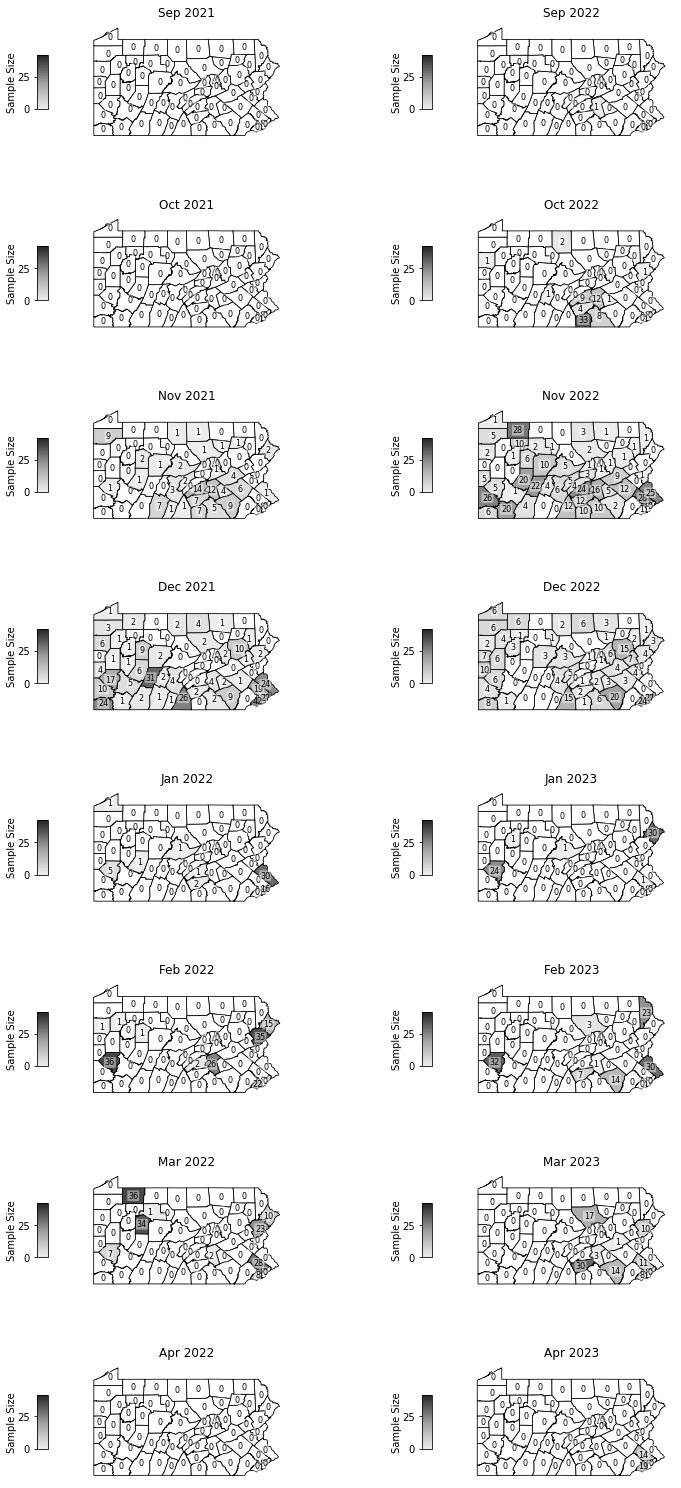

In [50]:
# Make lowercase copies (do not modify originals)
_penn = penn_map.copy()
_penn['COUNTY_NAME'] = _penn['COUNTY_NAME'].str.lower()
_df = pcr_sero.copy()
_df['Deer Harvest County'] = _df['Deer Harvest County'].str.lower()

# Time windows
_months = pd.to_datetime(_df['MonthYear'], errors='coerce')
# Month starts you want (8 months per season)
months_21_22 = pd.date_range('2021-09-01', '2022-04-01', freq='MS')
months_22_23 = pd.date_range('2022-09-01', '2023-04-01', freq='MS')

# All months you will plot (16 total)
all_months = months_21_22.append(months_22_23)

# Counts + merge for each month
merged_by_month = {}
for m in all_months:
    counts_m = _df.loc[_months == m, 'Deer Harvest County'].value_counts().reset_index()
    counts_m.columns = ['county_name_lower', 'Frequency']

    merged_m = _penn.merge(counts_m, left_on='COUNTY_NAME', right_on='county_name_lower', how='left')
    merged_m = gpd.GeoDataFrame(merged_m, geometry=_penn.geometry.name, crs=_penn.crs)
    merged_m['Frequency'] = merged_m['Frequency'].fillna(0).astype(int)

    merged_by_month[m] = merged_m

# Shared colormap and normalization across both maps
colors = ['#f0f0f0', '#9e9e9e', '#252525']
cmap = mcolors.LinearSegmentedColormap.from_list('custom_cmap', colors, N=256)
global_vmax = max(1, *(gdf['Frequency'].max() for gdf in merged_by_month.values()))
norm = mcolors.Normalize(vmin=0, vmax=global_vmax)

# Create two panels
fig, axes = plt.subplots(nrows=8, ncols=2, figsize=(12, 28))
plt.subplots_adjust(hspace=0.05, wspace=0.35)
for i, (m_left, m_right) in enumerate(zip(months_21_22, months_22_23)):
    for j, m in enumerate([m_left, m_right]):
        ax = axes[i, j]
        merged_gdf = merged_by_month[m]
        title = m.strftime('%b %Y')
        # Base (zero) layer
        zero_gdf = merged_gdf[merged_gdf['Frequency'] == 0]
        if not zero_gdf.empty:
            zero_gdf.plot(
            color='white',
            linewidth=0.8,
            ax=ax,
            edgecolor='black',
            legend=False
        )

        # Non-zero layer
        non_zero_gdf = merged_gdf[merged_gdf['Frequency'] > 0]
        if not non_zero_gdf.empty:
            non_zero_gdf.plot(
            column='Frequency',
            cmap=cmap,
            norm=norm,
            linewidth=0.8,
            ax=ax,
            edgecolor='black',
            legend=False
        )

        # Labels
        for _, row in merged_gdf.iterrows():
            geom = row.geometry
            if geom is None or geom.is_empty:
                continue

            c = geom.representative_point()  # safer than centroid for odd geometries
            if not (np.isfinite(c.x) and np.isfinite(c.y)):
                continue

            freq = row['Frequency']
            ax.text(
                c.x, c.y,
                str(int(freq)),
                fontsize=8,
                ha='center',
                va='center',
                bbox=dict(boxstyle="round,pad=0.1", facecolor="white", alpha=0.45, edgecolor="none")
            )

        # Ticks/labels (match your formatting)
        xticks = [-80, -79, -78, -77, -76, -75]
        yticks = [40, 40.5, 41, 41.5, 42]
        #ax.set_xticks(xticks)
        #ax.set_yticks(yticks)
        #ax.set_xticklabels([f'{abs(x)}W' for x in xticks],fontsize=9)
        #ax.set_yticklabels([f'{y}N' for y in yticks],fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])

        # Colorbar (right of each subplot)
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("left", size="4%", pad=0.05)
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = fig.colorbar(sm, cax=cax)
        cbar.ax.set_aspect(5)
        cbar.set_label('Sample Size', fontsize=10,labelpad=0)
        cbar.ax.yaxis.set_label_position('left')

        # Styling
        ax.set_title(title, fontsize=12)
        ax.title.set_position((0.5, 0.4))
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)
        cbar.ax.yaxis.tick_left()

del _penn, _df, _months
del months_21_22, months_22_23, all_months, merged_by_month
del zero_gdf, non_zero_gdf, c, row, freq, xticks, yticks, divider, cax, sm, cbar
fig.savefig('../USDA_meeting_1_9_2026/sample_by_month.png',format='png',dpi=600,bbox_inches='tight')

In [30]:
# Make lowercase copies (do not modify originals)
_penn = penn_map.copy()
_penn['COUNTY_NAME'] = _penn['COUNTY_NAME'].str.lower()
_df = pcr_sero.copy()
_df['Deer Harvest County'] = _df['Deer Harvest County'].str.lower()

# Time windows
_months = pd.to_datetime(_df['MonthYear'], errors='coerce')
# Month starts you want (8 months per season)
months_21_22 = pd.date_range('2021-09-01', '2022-04-01', freq='MS')
months_22_23 = pd.date_range('2022-09-01', '2023-04-01', freq='MS')

# All months you will plot (16 total)
all_months = months_21_22.append(months_22_23)

# Counts + merge for each month
merged_by_month = {}
for m in all_months:
    counts_m = _df.loc[_months == m, 'Deer Harvest County'].value_counts().reset_index()
    counts_m.columns = ['county_name_lower', 'Frequency']

    merged_m = _penn.merge(counts_m, left_on='COUNTY_NAME', right_on='county_name_lower', how='left')
    merged_m['Frequency'] = merged_m['Frequency'].fillna(0)

    merged_by_month[m] = merged_m

# Shared colormap and normalization across both maps
colors = ['#f0f0f0', '#9e9e9e', '#252525']
cmap = mcolors.LinearSegmentedColormap.from_list('custom_cmap', colors, N=256)
global_vmax = max(1, *(gdf['Frequency'].max() for gdf in merged_by_month.values()))
norm = mcolors.Normalize(vmin=0, vmax=global_vmax)

# Create two panels
fig, axes = plt.subplots(nrows=8, ncols=2, figsize=(12, 28))
plt.subplots_adjust(hspace=0.05, wspace=0.35)
for i, (m_left, m_right) in enumerate(zip(months_21_22, months_22_23)):
    for j, m in enumerate([m_left, m_right]):
        ax = axes[i, j]
        merged_gdf = merged_by_month[m]
        title = m.strftime('%b %Y')
        # Base (zero) layer
        zero_gdf = merged_gdf[merged_gdf['Frequency'] == 0]
        zero_gdf.plot(
            color='white',
            linewidth=0.8,
            ax=ax,
            edgecolor='black',
            legend=False
        )

        # Non-zero layer
        non_zero_gdf = merged_gdf[merged_gdf['Frequency'] > 0]
        non_zero_gdf.plot(
            column='Frequency',
            cmap=cmap,
            norm=norm,
            linewidth=0.8,
            ax=ax,
            edgecolor='black',
            legend=False
        )

        # Labels
        for _, row in merged_gdf.iterrows():
            c = row.geometry.centroid
            freq = row['Frequency']
            ax.text(
                c.x, c.y,
                str(int(freq)),
                fontsize=8,
                ha='center',
                va='center',
                bbox=dict(boxstyle="round,pad=0.1", facecolor="white", alpha=0.45, edgecolor="none")
            )

        # Ticks/labels (match your formatting)
        xticks = [-80, -79, -78, -77, -76, -75]
        yticks = [40, 40.5, 41, 41.5, 42]
        #ax.set_xticks(xticks)
        #ax.set_yticks(yticks)
        #ax.set_xticklabels([f'{abs(x)}W' for x in xticks],fontsize=9)
        #ax.set_yticklabels([f'{y}N' for y in yticks],fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])

        # Colorbar (right of each subplot)
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("left", size="4%", pad=-0.6)
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = fig.colorbar(sm, cax=cax)
        cbar.ax.set_aspect(5)
        cbar.set_label('Sample Size', fontsize=10,labelpad=0)
        cbar.ax.yaxis.set_label_position('left')

        # Styling
        ax.set_title(title, fontsize=12)
        ax.title.set_position((0.5, 0.4))
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)
        cbar.ax.yaxis.tick_left()

del _penn, _df, _months
del months_21_22, months_22_23, all_months, merged_by_month
del zero_gdf, non_zero_gdf, c, row, freq, xticks, yticks, divider, cax, sm, cbar
#fig.savefig('./PCR_sero_sample_sizes_2021_2022.png',format='png',dpi=600,bbox_inches='tight')

C:\ProgramData\Anaconda3\lib\site-packages\geopandas\plotting.py:695: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  warnings.warn(
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should

KeyboardInterrupt: 

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

AttributeError: 'NoneType' object has no attribute 'extents'

<Figure size 864x2016 with 18 Axes>

In [28]:
# Labels
for _, row in merged_gdf.iterrows():
    c = row.geometry.centroid
    print(c)
    freq = row['Frequency']
    ax.text(
        c.x, c.y,
        str(int(freq)),
        fontsize=8,
        ha='center',
        va='center',
        bbox=dict(boxstyle="round,pad=0.1", facecolor="white", alpha=0.45, edgecolor="none")
    )

POINT (-75.36728825541672 40.21081577628156)
POINT (-76.51541840470797 41.788654024557616)
POINT (-75.10690343557951 40.33694921831423)
POINT (-77.25423497088104 41.772156601430005)
POINT (-77.06202106996713 40.963006144057)
POINT (-79.75807881473413 41.40091116047928)
POINT (-80.24840909783528 40.189606035322285)
POINT (-75.30319948416808 41.64880105656567)
POINT (-78.56913781374479 41.80768887049766)
POINT (-80.25812324355927 41.30242039254419)
POINT (-77.61709138090666 40.61040080236529)
POINT (-76.65861154543943 41.02799174278642)
POINT (-75.30762838841436 40.754172755649776)
POINT (-76.70926309790599 40.85194287758761)
POINT (-77.26122542365974 40.398805448395066)
POINT (-75.03387961678098 41.33195315119966)
POINT (-77.89580386778425 41.74493098481443)
POINT (-76.21594343997465 40.705845527966694)
POINT (-77.07020484146311 40.76984064691135)
POINT (-79.02817008668784 39.97249462098523)
POINT (-76.5120925656917 41.44605112998489)
POINT (-76.45780865682845 40.367295359497845)
POINT 

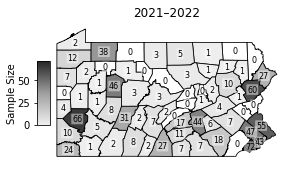

In [5]:
# Make lowercase copies (do not modify originals)
_penn = penn_map.copy()
_penn['COUNTY_NAME'] = _penn['COUNTY_NAME'].str.lower()
_df = pcr_sero.copy()
_df['Deer Harvest County'] = _df['Deer Harvest County'].str.lower()

# Time windows
_months = pd.to_datetime(_df['MonthYear'], errors='coerce')
mask_21_22 = (_months >= pd.Timestamp('2021-09-01')) & (_months <= pd.Timestamp('2022-04-01'))
mask_22_23 = (_months >= pd.Timestamp('2022-09-01')) & (_months <= pd.Timestamp('2023-04-01'))

# Counts per county for each period
counts_21_22 = _df.loc[mask_21_22, 'Deer Harvest County'].value_counts().reset_index()
counts_21_22.columns = ['county_name_lower', 'Frequency']
counts_22_23 = _df.loc[mask_22_23, 'Deer Harvest County'].value_counts().reset_index()
counts_22_23.columns = ['county_name_lower', 'Frequency']

# Merge with county polygons
merged_21_22 = _penn.merge(counts_21_22, left_on='COUNTY_NAME', right_on='county_name_lower', how='left')
merged_22_23 = _penn.merge(counts_22_23, left_on='COUNTY_NAME', right_on='county_name_lower', how='left')
merged_21_22['Frequency'] = merged_21_22['Frequency'].fillna(0)
merged_22_23['Frequency'] = merged_22_23['Frequency'].fillna(0)

# Shared colormap and normalization across both maps
colors = ['#f0f0f0', '#9e9e9e', '#252525']
cmap = mcolors.LinearSegmentedColormap.from_list('custom_cmap', colors, N=256)
global_vmax = max(1, merged_21_22['Frequency'].max(), merged_22_23['Frequency'].max())
norm = mcolors.Normalize(vmin=0, vmax=global_vmax)

# Create two panels
fig, axes = plt.subplots( figsize=(5.2, 5))
plt.subplots_adjust(hspace=-0.1)
for ax, merged_gdf, title in [
    (axes, merged_21_22, "2021–2022")
]:
    # Base (zero) layer
    zero_gdf = merged_gdf[merged_gdf['Frequency'] == 0]
    zero_gdf.plot(
        color='white',
        linewidth=0.8,
        ax=ax,
        edgecolor='black',
        legend=False
    )

    # Non-zero layer
    non_zero_gdf = merged_gdf[merged_gdf['Frequency'] > 0]
    non_zero_gdf.plot(
        column='Frequency',
        cmap=cmap,
        norm=norm,
        linewidth=0.8,
        ax=ax,
        edgecolor='black',
        legend=False
    )

    # Labels
    for _, row in merged_gdf.iterrows():
        c = row.geometry.centroid
        freq = row['Frequency']
        ax.text(
            c.x, c.y,
            str(int(freq)),
            fontsize=8,
            ha='center',
            va='center',
            bbox=dict(boxstyle="round,pad=0.1", facecolor="white", alpha=0.45, edgecolor="none")
        )

    # Ticks/labels (match your formatting)
    xticks = [-80, -79, -78, -77, -76, -75]
    yticks = [40, 40.5, 41, 41.5, 42]
    #ax.set_xticks(xticks)
    #ax.set_yticks(yticks)
    #ax.set_xticklabels([f'{abs(x)}W' for x in xticks],fontsize=9)
    #ax.set_yticklabels([f'{y}N' for y in yticks],fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])

    # Colorbar (right of each subplot)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("left", size="4%", pad=-0.6)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cax)
    cbar.ax.set_aspect(5)
    cbar.set_label('Sample Size', fontsize=10,labelpad=0)
    cbar.ax.yaxis.set_label_position('left')
    
    # Styling
    ax.set_title(title, fontsize=12)
    ax.title.set_position((0.5, 0.4))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    cbar.ax.yaxis.tick_left()

del _penn, _df, _months, mask_21_22, mask_22_23
del counts_21_22, counts_22_23, merged_21_22, merged_22_23
del zero_gdf, non_zero_gdf, c, row, freq, xticks, yticks, divider, cax, sm, cbar
#fig.savefig('./PCR_sero_sample_sizes_2021_2022.png',format='png',dpi=600,bbox_inches='tight')

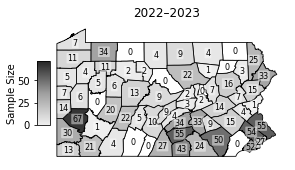

In [29]:
# Make lowercase copies (do not modify originals)
_penn = penn_map.copy()
_penn['COUNTY_NAME'] = _penn['COUNTY_NAME'].str.lower()
_df = pcr_sero.copy()
_df['Deer Harvest County'] = _df['Deer Harvest County'].str.lower()

# Time windows
_months = pd.to_datetime(_df['MonthYear'], errors='coerce')
mask_21_22 = (_months >= pd.Timestamp('2021-09-01')) & (_months <= pd.Timestamp('2022-04-01'))
mask_22_23 = (_months >= pd.Timestamp('2022-09-01')) & (_months <= pd.Timestamp('2023-04-01'))

# Counts per county for each period
counts_21_22 = _df.loc[mask_21_22, 'Deer Harvest County'].value_counts().reset_index()
counts_21_22.columns = ['county_name_lower', 'Frequency']
counts_22_23 = _df.loc[mask_22_23, 'Deer Harvest County'].value_counts().reset_index()
counts_22_23.columns = ['county_name_lower', 'Frequency']

# Merge with county polygons
merged_21_22 = _penn.merge(counts_21_22, left_on='COUNTY_NAME', right_on='county_name_lower', how='left')
merged_22_23 = _penn.merge(counts_22_23, left_on='COUNTY_NAME', right_on='county_name_lower', how='left')
merged_21_22['Frequency'] = merged_21_22['Frequency'].fillna(0)
merged_22_23['Frequency'] = merged_22_23['Frequency'].fillna(0)

# Shared colormap and normalization across both maps
colors = ['#f0f0f0', '#9e9e9e', '#252525']
cmap = mcolors.LinearSegmentedColormap.from_list('custom_cmap', colors, N=256)
global_vmax = max(1, merged_21_22['Frequency'].max(), merged_22_23['Frequency'].max())
norm = mcolors.Normalize(vmin=0, vmax=global_vmax)

# Create two panels
fig, axes = plt.subplots( figsize=(5.2, 5))
plt.subplots_adjust(hspace=-0.25)
for ax, merged_gdf, title in [
    (axes, merged_22_23, "2022–2023")
]:
    # Base (zero) layer
    zero_gdf = merged_gdf[merged_gdf['Frequency'] == 0]
    zero_gdf.plot(
        color='white',
        linewidth=0.8,
        ax=ax,
        edgecolor='black',
        legend=False
    )

    # Non-zero layer
    non_zero_gdf = merged_gdf[merged_gdf['Frequency'] > 0]
    non_zero_gdf.plot(
        column='Frequency',
        cmap=cmap,
        norm=norm,
        linewidth=0.8,
        ax=ax,
        edgecolor='black',
        legend=False
    )

    # Labels
    for _, row in merged_gdf.iterrows():
        c = row.geometry.centroid
        freq = row['Frequency']
        ax.text(
            c.x, c.y,
            str(int(freq)),
            fontsize=8,
            ha='center',
            va='center',
            bbox=dict(boxstyle="round,pad=0.1", facecolor="white", alpha=0.45, edgecolor="none")
        )

    # Ticks/labels (match your formatting)
    xticks = [-80, -79, -78, -77, -76, -75]
    yticks = [40, 40.5, 41, 41.5, 42]
    #ax.set_xticks(xticks)
    #ax.set_yticks(yticks)
    #ax.set_xticklabels([f'{abs(x)}W' for x in xticks],fontsize=9)
    #ax.set_yticklabels([f'{y}N' for y in yticks],fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
    
    # Colorbar (right of each subplot)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("left", size="4%", pad=-0.6)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cax)
    cbar.ax.set_aspect(5)
    cbar.set_label('Sample Size', fontsize=10,labelpad=0)
    cbar.ax.yaxis.set_label_position('left')
    
    # Styling
    ax.set_title(title, fontsize=12)
    ax.title.set_position((0.5, 0.4))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    cbar.ax.yaxis.tick_left()

del _penn, _df, _months, mask_21_22, mask_22_23
del counts_21_22, counts_22_23, merged_21_22, merged_22_23
del zero_gdf, non_zero_gdf, c, row, freq, xticks, yticks, divider, cax, sm, cbar
#fig.savefig('./PCR_sero_sample_sizes_2022_2023.png',format='png',dpi=600,bbox_inches='tight')

# PCR positivity rate

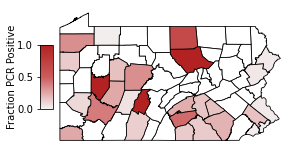

In [33]:
# Make lowercase copies (do not modify originals)
_penn = penn_map.copy()
_penn['COUNTY_NAME'] = _penn['COUNTY_NAME'].str.lower()
_df = pcr_sero.copy()
_df['Deer Harvest County'] = _df['Deer Harvest County'].str.lower()

# Time windows
_months = pd.to_datetime(_df['MonthYear'], errors='coerce')
mask_21_22 = (_months >= pd.Timestamp('2021-09-01')) & (_months <= pd.Timestamp('2022-04-01'))
mask_22_23 = (_months >= pd.Timestamp('2022-09-01')) & (_months <= pd.Timestamp('2023-04-01'))

# Helper: per-county PCR positivity (positives / total) for a given mask
def _county_pos_rate(mask):
    tmp = _df.loc[mask, ['Deer Harvest County', 'PCR Testing Result']].copy()
    tmp['is_pos'] = tmp['PCR Testing Result'].astype(str).str.strip().str.lower().eq('positive').astype(int)
    grp = tmp.groupby('Deer Harvest County', as_index=False).agg(
        Total=('PCR Testing Result', 'size'),
        Pos=('is_pos', 'sum')
    )
    grp['PosRate'] = grp['Pos'] / grp['Total']
    return grp[['Deer Harvest County', 'PosRate']].rename(columns={'Deer Harvest County': 'county_name_lower'})

# Per-season county positivity
pos_21_22 = _county_pos_rate(mask_21_22)
pos_22_23 = _county_pos_rate(mask_22_23)

# Merge with county polygons
merged_21_22 = _penn.merge(pos_21_22, left_on='COUNTY_NAME', right_on='county_name_lower', how='left')
merged_22_23 = _penn.merge(pos_22_23, left_on='COUNTY_NAME', right_on='county_name_lower', how='left')
merged_21_22['PosRate'] = merged_21_22['PosRate'].fillna(0.0)
merged_22_23['PosRate'] = merged_22_23['PosRate'].fillna(0.0)

# Shared colormap and normalization across both maps (use same max so scales match)
colors = ['whitesmoke', 'indianred', 'firebrick']
cmap = mcolors.LinearSegmentedColormap.from_list('custom_cmap', colors, N=256)
global_vmax = max(merged_21_22['PosRate'].max(), merged_22_23['PosRate'].max())
norm = mcolors.Normalize(vmin=0, vmax=global_vmax if global_vmax > 0 else 1)

# Create two panels
fig, axes = plt.subplots( figsize=(5.2, 5))


for ax, merged_gdf, title in [
    (axes, merged_21_22, "2021–2022"),]:
    # Base (zero) layer
    zero_gdf = merged_gdf[merged_gdf['PosRate'] == 0]
    zero_gdf.plot(
        color='white',
        linewidth=0.8,
        ax=ax,
        edgecolor='black',
        legend=False
    )

    # Non-zero layer
    non_zero_gdf = merged_gdf[merged_gdf['PosRate'] > 0]
    non_zero_gdf.plot(
        column='PosRate',
        cmap=cmap,
        norm=norm,
        linewidth=0.8,
        ax=ax,
        edgecolor='black',
        legend=False
    )

    # Labels (percentage)
    for _, row in merged_gdf.iterrows():
        c = row.geometry.centroid
        rate = float(row['PosRate']) if row['PosRate'] == row['PosRate'] else 0.0  # handle NaN
        #ax.text(
        #    c.x, c.y,
        #    f"{rate*100:.0f}%",  # whole-percent label
        #    fontsize=12,
        #    ha='center',
        #    va='center',
        #    bbox=dict(boxstyle="round,pad=0.1", facecolor="white", alpha=0.7, edgecolor="none")
        #)

    # Ticks/labels (match your formatting)
    xticks = [-80, -79, -78, -77, -76, -75]
    yticks = [40, 40.5, 41, 41.5, 42]
    #ax.set_xticks(xticks)
    #ax.set_yticks(yticks)
    #ax.set_xticklabels([f'{abs(x)}W' for x in xticks],fontsize=9)
    #ax.set_yticklabels([f'{y}N' for y in yticks],fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])

        # Colorbar (right of each subplot)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("left", size="4%", pad=-0.6)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cax)
    cbar.ax.set_aspect(5)
    cbar.set_label('Fraction PCR Positive', fontsize=10,labelpad=0)
    cbar.ax.yaxis.set_label_position('left')
    
    # Styling
    #ax.set_title(title, fontsize=12)
    ax.title.set_position((0.5, 0.4))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    cbar.ax.yaxis.tick_left()

# Optional: clean up temporaries
del _penn, _df, _months, mask_21_22, mask_22_23
del pos_21_22, pos_22_23, merged_21_22, merged_22_23
del zero_gdf, non_zero_gdf, c, row, rate, xticks, yticks, divider, cax, sm, cbar
#fig.savefig('./PCR_sero_PCR_positivity_rates_2021_2022.png',format='png',dpi=600,bbox_inches='tight')

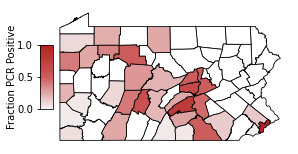

In [34]:
# Make lowercase copies (do not modify originals)
_penn = penn_map.copy()
_penn['COUNTY_NAME'] = _penn['COUNTY_NAME'].str.lower()
_df = pcr_sero.copy()
_df['Deer Harvest County'] = _df['Deer Harvest County'].str.lower()

# Time windows
_months = pd.to_datetime(_df['MonthYear'], errors='coerce')
mask_21_22 = (_months >= pd.Timestamp('2021-09-01')) & (_months <= pd.Timestamp('2022-04-01'))
mask_22_23 = (_months >= pd.Timestamp('2022-09-01')) & (_months <= pd.Timestamp('2023-04-01'))

# Helper: per-county PCR positivity (positives / total) for a given mask
def _county_pos_rate(mask):
    tmp = _df.loc[mask, ['Deer Harvest County', 'PCR Testing Result']].copy()
    tmp['is_pos'] = tmp['PCR Testing Result'].astype(str).str.strip().str.lower().eq('positive').astype(int)
    grp = tmp.groupby('Deer Harvest County', as_index=False).agg(
        Total=('PCR Testing Result', 'size'),
        Pos=('is_pos', 'sum')
    )
    grp['PosRate'] = grp['Pos'] / grp['Total']
    return grp[['Deer Harvest County', 'PosRate']].rename(columns={'Deer Harvest County': 'county_name_lower'})

# Per-season county positivity
pos_21_22 = _county_pos_rate(mask_21_22)
pos_22_23 = _county_pos_rate(mask_22_23)

# Merge with county polygons
merged_21_22 = _penn.merge(pos_21_22, left_on='COUNTY_NAME', right_on='county_name_lower', how='left')
merged_22_23 = _penn.merge(pos_22_23, left_on='COUNTY_NAME', right_on='county_name_lower', how='left')
merged_21_22['PosRate'] = merged_21_22['PosRate'].fillna(0.0)
merged_22_23['PosRate'] = merged_22_23['PosRate'].fillna(0.0)

# Shared colormap and normalization across both maps (use same max so scales match)
colors = ['whitesmoke', 'indianred', 'firebrick']
cmap = mcolors.LinearSegmentedColormap.from_list('custom_cmap', colors, N=256)
global_vmax = max(merged_21_22['PosRate'].max(), merged_22_23['PosRate'].max())
norm = mcolors.Normalize(vmin=0, vmax=global_vmax if global_vmax > 0 else 1)

# Create two panels
fig, axes = plt.subplots(figsize=(5.2, 5))


for ax, merged_gdf, title in [
    (axes, merged_22_23, "2022–2023")
]:
    # Base (zero) layer
    zero_gdf = merged_gdf[merged_gdf['PosRate'] == 0]
    zero_gdf.plot(
        color='white',
        linewidth=0.8,
        ax=ax,
        edgecolor='black',
        legend=False
    )

    # Non-zero layer
    non_zero_gdf = merged_gdf[merged_gdf['PosRate'] > 0]
    non_zero_gdf.plot(
        column='PosRate',
        cmap=cmap,
        norm=norm,
        linewidth=0.8,
        ax=ax,
        edgecolor='black',
        legend=False
    )

    # Labels (percentage)
    for _, row in merged_gdf.iterrows():
        c = row.geometry.centroid
        rate = float(row['PosRate']) if row['PosRate'] == row['PosRate'] else 0.0  # handle NaN
        #ax.text(
        #    c.x, c.y,
        #    f"{rate*100:.0f}%",  # whole-percent label
        #    fontsize=12,
        #    ha='center',
        #    va='center',
        #    bbox=dict(boxstyle="round,pad=0.1", facecolor="white", alpha=0.7, edgecolor="none")
        #)

    # Ticks/labels (match your formatting)
    xticks = [-80, -79, -78, -77, -76, -75]
    yticks = [40, 40.5, 41, 41.5, 42]
#     ax.set_xticks(xticks)
#     ax.set_yticks(yticks)
#     ax.set_xticklabels([f'{abs(x)}W' for x in xticks],fontsize=9)
#     ax.set_yticklabels([f'{y}N' for y in yticks],fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])

     # Colorbar (right of each subplot)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("left", size="4%", pad=-0.6)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cax)
    cbar.ax.set_aspect(5)
    cbar.set_label('Fraction PCR Positive', fontsize=10,labelpad=0)
    cbar.ax.yaxis.set_label_position('left')
    
    # Styling
    #ax.set_title(title, fontsize=12)
    ax.title.set_position((0.5, 0.4))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    cbar.ax.yaxis.tick_left()

# Optional: clean up temporaries
del _penn, _df, _months, mask_21_22, mask_22_23
del pos_21_22, pos_22_23, merged_21_22, merged_22_23
del zero_gdf, non_zero_gdf, c, row, rate, xticks, yticks, divider, cax, sm, cbar
#fig.savefig('./PCR_sero_PCR_positivity_rates_2022_2023.png',format='png',dpi=600,bbox_inches='tight')

# Seropositivity rate

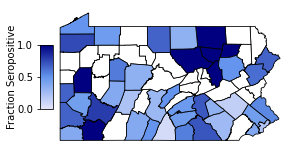

In [35]:
# Make lowercase copies (do not modify originals)
_penn = penn_map.copy()
_penn['COUNTY_NAME'] = _penn['COUNTY_NAME'].str.lower()
_df = pcr_sero.copy()
_df['Deer Harvest County'] = _df['Deer Harvest County'].str.lower()

# Time windows
_months = pd.to_datetime(_df['MonthYear'], errors='coerce')
mask_21_22 = (_months >= pd.Timestamp('2021-09-01')) & (_months <= pd.Timestamp('2022-04-01'))
mask_22_23 = (_months >= pd.Timestamp('2022-09-01')) & (_months <= pd.Timestamp('2023-04-01'))

# Helper: per-county seropositivity (positives / total) for a given mask
def _county_sero_rate(mask):
    tmp = _df.loc[mask, ['Deer Harvest County', 'Serology Testing Result']].copy()
    tmp['is_pos'] = tmp['Serology Testing Result'].astype(str).str.strip().str.lower().eq('positive').astype(int)
    grp = tmp.groupby('Deer Harvest County', as_index=False).agg(
        Total=('Serology Testing Result', 'size'),
        Pos=('is_pos', 'sum')
    )
    grp['SeroRate'] = grp['Pos'] / grp['Total']
    return grp[['Deer Harvest County', 'SeroRate']].rename(columns={'Deer Harvest County': 'county_name_lower'})

# Per-season county seropositivity
sero_21_22 = _county_sero_rate(mask_21_22)
sero_22_23 = _county_sero_rate(mask_22_23)

# Merge with county polygons
merged_21_22 = _penn.merge(sero_21_22, left_on='COUNTY_NAME', right_on='county_name_lower', how='left')
merged_22_23 = _penn.merge(sero_22_23, left_on='COUNTY_NAME', right_on='county_name_lower', how='left')
merged_21_22['SeroRate'] = merged_21_22['SeroRate'].fillna(0.0)
merged_22_23['SeroRate'] = merged_22_23['SeroRate'].fillna(0.0)

# Shared colormap and normalization across both maps (use same max so scales match)
colors = ['lavender', 'cornflowerblue', 'navy']
cmap = mcolors.LinearSegmentedColormap.from_list('custom_cmap', colors, N=256)
global_vmax = max(merged_21_22['SeroRate'].max(), merged_22_23['SeroRate'].max())
norm = mcolors.Normalize(vmin=0, vmax=global_vmax if global_vmax > 0 else 1)

# Create two panels
fig, axes = plt.subplots(figsize=(5.2, 5))


for ax, merged_gdf, title in [
    (axes, merged_21_22, "2021–2022")
]:
    # Base (zero) layer
    zero_gdf = merged_gdf[merged_gdf['SeroRate'] == 0]
    zero_gdf.plot(
        color='white',
        linewidth=0.8,
        ax=ax,
        edgecolor='black',
        legend=False
    )

    # Non-zero layer
    non_zero_gdf = merged_gdf[merged_gdf['SeroRate'] > 0]
    non_zero_gdf.plot(
        column='SeroRate',
        cmap=cmap,
        norm=norm,
        linewidth=0.8,
        ax=ax,
        edgecolor='black',
        legend=False
    )

    # Labels (percentage)
    for _, row in merged_gdf.iterrows():
        c = row.geometry.centroid
        rate = float(row['SeroRate']) if row['SeroRate'] == row['SeroRate'] else 0.0  # handle NaN
        #ax.text(
        #    c.x, c.y,
        #    f"{rate*100:.0f}%",
        #    fontsize=12,
        #    ha='center',
        #    va='center',
        #    bbox=dict(boxstyle="round,pad=0.1", facecolor="white", alpha=0.7, edgecolor="none")
        #)

    # Ticks/labels (match your formatting)
    xticks = [-80, -79, -78, -77, -76, -75]
    yticks = [40, 40.5, 41, 41.5, 42]
    #ax.set_xticks(xticks)
    #ax.set_yticks(yticks)
    #ax.set_xticklabels([f'{abs(x)}W' for x in xticks])
    #ax.set_yticklabels([f'{y}N' for y in yticks])
    ax.set_xticks([])
    ax.set_yticks([])
     # Colorbar (right of each subplot)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("left", size="4%", pad=-0.6)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cax)
    cbar.ax.set_aspect(5)
    cbar.set_label('Fraction Seropositive', fontsize=10,labelpad=0)
    cbar.ax.yaxis.set_label_position('left')
    
    # Styling
    #ax.set_title(title, fontsize=12)
    ax.title.set_position((0.5, 0.4))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    cbar.ax.yaxis.tick_left()

# Optional: clean up temporaries
del _penn, _df, _months, mask_21_22, mask_22_23
del sero_21_22, sero_22_23, merged_21_22, merged_22_23
del zero_gdf, non_zero_gdf, c, row, rate, xticks, yticks, divider, cax, sm, cbar
#fig.savefig('./PCR_sero_seropositivity_rates_2021_2022.png',format='png',dpi=600,bbox_inches='tight')

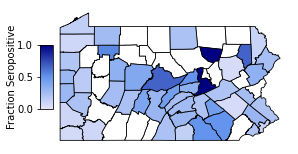

In [36]:
# Make lowercase copies (do not modify originals)
_penn = penn_map.copy()
_penn['COUNTY_NAME'] = _penn['COUNTY_NAME'].str.lower()
_df = pcr_sero.copy()
_df['Deer Harvest County'] = _df['Deer Harvest County'].str.lower()

# Time windows
_months = pd.to_datetime(_df['MonthYear'], errors='coerce')
mask_21_22 = (_months >= pd.Timestamp('2021-09-01')) & (_months <= pd.Timestamp('2022-04-01'))
mask_22_23 = (_months >= pd.Timestamp('2022-09-01')) & (_months <= pd.Timestamp('2023-04-01'))

# Helper: per-county seropositivity (positives / total) for a given mask
def _county_sero_rate(mask):
    tmp = _df.loc[mask, ['Deer Harvest County', 'Serology Testing Result']].copy()
    tmp['is_pos'] = tmp['Serology Testing Result'].astype(str).str.strip().str.lower().eq('positive').astype(int)
    grp = tmp.groupby('Deer Harvest County', as_index=False).agg(
        Total=('Serology Testing Result', 'size'),
        Pos=('is_pos', 'sum')
    )
    grp['SeroRate'] = grp['Pos'] / grp['Total']
    return grp[['Deer Harvest County', 'SeroRate']].rename(columns={'Deer Harvest County': 'county_name_lower'})

# Per-season county seropositivity
sero_21_22 = _county_sero_rate(mask_21_22)
sero_22_23 = _county_sero_rate(mask_22_23)

# Merge with county polygons
merged_21_22 = _penn.merge(sero_21_22, left_on='COUNTY_NAME', right_on='county_name_lower', how='left')
merged_22_23 = _penn.merge(sero_22_23, left_on='COUNTY_NAME', right_on='county_name_lower', how='left')
merged_21_22['SeroRate'] = merged_21_22['SeroRate'].fillna(0.0)
merged_22_23['SeroRate'] = merged_22_23['SeroRate'].fillna(0.0)

# Shared colormap and normalization across both maps (use same max so scales match)
colors = ['lavender', 'cornflowerblue', 'navy']
cmap = mcolors.LinearSegmentedColormap.from_list('custom_cmap', colors, N=256)
global_vmax = max(merged_21_22['SeroRate'].max(), merged_22_23['SeroRate'].max())
norm = mcolors.Normalize(vmin=0, vmax=global_vmax if global_vmax > 0 else 1)

# Create two panels
fig, axes = plt.subplots(figsize=(5.2, 5))


for ax, merged_gdf, title in [
    (axes, merged_22_23, "2022–2023")
]:
    # Base (zero) layer
    zero_gdf = merged_gdf[merged_gdf['SeroRate'] == 0]
    zero_gdf.plot(
        color='white',
        linewidth=0.8,
        ax=ax,
        edgecolor='black',
        legend=False
    )

    # Non-zero layer
    non_zero_gdf = merged_gdf[merged_gdf['SeroRate'] > 0]
    non_zero_gdf.plot(
        column='SeroRate',
        cmap=cmap,
        norm=norm,
        linewidth=0.8,
        ax=ax,
        edgecolor='black',
        legend=False
    )

    # Labels (percentage)
    for _, row in merged_gdf.iterrows():
        c = row.geometry.centroid
        rate = float(row['SeroRate']) if row['SeroRate'] == row['SeroRate'] else 0.0  # handle NaN
        #ax.text(
        #    c.x, c.y,
        #    f"{rate*100:.0f}%",
        #    fontsize=12,
        #    ha='center',
        #    va='center',
        #    bbox=dict(boxstyle="round,pad=0.1", facecolor="white", alpha=0.7, edgecolor="none")
        #)

    # Ticks/labels (match your formatting)
    xticks = [-80, -79, -78, -77, -76, -75]
    yticks = [40, 40.5, 41, 41.5, 42]
    #ax.set_xticks(xticks)
    #ax.set_yticks(yticks)
    #ax.set_xticklabels([f'{abs(x)}W' for x in xticks])
    #ax.set_yticklabels([f'{y}N' for y in yticks])
    ax.set_xticks([])
    ax.set_yticks([])
     # Colorbar (right of each subplot)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("left", size="4%", pad=-0.6)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cax)
    cbar.ax.set_aspect(5)
    cbar.set_label('Fraction Seropositive', fontsize=10,labelpad=0)
    cbar.ax.yaxis.set_label_position('left')
    
    # Styling
    #ax.set_title(title, fontsize=12)
    ax.title.set_position((0.5, 0.4))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    cbar.ax.yaxis.tick_left()

# Optional: clean up temporaries
del _penn, _df, _months, mask_21_22, mask_22_23
del sero_21_22, sero_22_23, merged_21_22, merged_22_23
del zero_gdf, non_zero_gdf, c, row, rate, xticks, yticks, divider, cax, sm, cbar
#fig.savefig('./PCR_sero_seropositivity_rates_2022_2023.png',format='png',dpi=600,bbox_inches='tight')